# Part B · NB5 — Final Comparison (Label-Efficiency vs Part A)  ·  `pavecrack1300-partb-comparison`

**Course:** CSE 438 — Digital Image Processing · EWU · Summer 2026 · **Group:** _`<fill>`_

Pulls each SSL method's `results_partB.json` **and** the Part-A `results.json`, then builds the **label-efficiency**
table + chart (Task E) and consolidated error analysis (Task F). Attach all four method outputs **and** the Part-A
NB1/NB2/NB3 output (for its `results.json`).

In [1]:
import glob, json
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt
WORK = Path("/kaggle/working")
# merge all Part-B method results
pb = {}
for rp in glob.glob("/kaggle/input/**/results_partB.json", recursive=True):
    try: pb.update(json.load(open(rp)))
    except Exception as e: print("skip", rp, e)
# Part-A supervised baseline (best model = DeepLabV3)
partA = {}
for rp in glob.glob("/kaggle/input/**/results.json", recursive=True):
    try: partA.update(json.load(open(rp)))
    except Exception: pass
baseline = max(partA.values(), key=lambda r: r.get("miou", 0)) if partA else None
print("Part-B methods:", list(pb.keys()))
if partA:
    print("Part-A models found :", {k: round(v.get("miou", 0), 4) for k, v in partA.items()})
print("Part-A BEST baseline:", f'{baseline["model"]} (mIoU {baseline["miou"]:.4f}, {baseline["params_M"]}M)' if baseline else "NOT FOUND - attach the Part-A output")
if baseline and len(partA) < 3:
    print("NOTE: fewer than 3 Part-A models in results.json - attach the Part-A NB3 (YOLO) output,")
    print("      which merges DeepLabV3 + SegFormer + YOLO, so the best model is chosen correctly.")
plt.rcParams.update({"figure.dpi": 110, "font.size": 10, "axes.titlesize": 11, "axes.titleweight": "bold",
                     "axes.spines.top": False, "axes.spines.right": False, "legend.frameon": False})
PALETTE = {"SimCLR": "#4C72B0", "BYOL": "#DD8452", "MAE": "#55A868", "DINOv2": "#C44E52",
           "SimCLR-frozen": "#8172B3", "Part-A supervised": "#333333"}

Part-B methods: ['MAE', 'BYOL', 'DINOv2', 'SimCLR-frozen', 'SimCLR']
Part-A models found : {'SegFormer-B0': 0.8048, 'DeepLabV3-ResNet50': 0.824, 'YOLO26s-Sem': 0.8319}
Part-A BEST baseline: YOLO26s-Sem (mIoU 0.8319, 6.49M)


## Task E — label-efficiency comparison table

**How to read this table honestly — two caveats that must appear in the report (§6.3, §6.8):**

1. **Label budget (the point of the experiment).** Every SSL row was fine-tuned on the **Part-A validation split
   (195 labelled images)**; the Part-A supervised baseline was trained on the **full Part-A train split
   (909 labelled images)**. So the SSL rows use **~21%** of the labels.
2. **Input resolution differs.** Part A trained/evaluated at **512×512**; Part B runs at **224×224** — the one
   resolution that every SSL encoder accepts (ResNet, and ViT-S/**14** → 16×16 tokens) and that fits the Kaggle
   T4 for multi-crop pretraining. Cracks are thin structures, so lower resolution costs IoU independently of the
   label budget. **Part of the Part-A → Part-B gap is therefore resolution, not only supervision.** We report the
   comparison as the assignment requires, but we do **not** claim the whole gap is a label-efficiency effect.


3. **The test split serves a double role.** Per the assignment's own simplification, the Part-A **test** split was
   used *both* to monitor fine-tuning / select the best checkpoint **and** to report these final metrics. It was
   therefore not a fully untouched hold-out, which **inflates** every Part-B number somewhat. The strictly correct
   fix would be a fourth, never-touched slice — not affordable here because the labelled set is only 195 images.
   State this explicitly in report §6.3.

*(The failure-overlap analysis further below is unaffected by this: it compares per-image **rankings** on the same
images, not absolute IoU values.)*

In [2]:
rows = []
N_LAB = next(iter(pb.values()))["n_labelled"] if pb else 195
for name in sorted(pb, key=lambda k: -pb[k]["miou"]):
    r = pb[name]
    rows.append(dict(Method=name, Backbone="ResNet-50" if name!="DINOv2" else "ViT-S/14",
                     Labels=r["n_labelled"], mIoU=round(r["miou"],4), CrackIoU=round(r["crack_iou"],4),
                     Dice=round(r["mdice"],4), Params_M=r["params_M"]))
if baseline:
    rows.append(dict(Method=f"Part-A supervised ({baseline['model']})", Backbone=baseline["model"],
                     Labels=909, mIoU=round(baseline["miou"],4), CrackIoU=round(baseline.get("crack_iou",baseline["per_class_iou"][1]),4),
                     Dice=round(baseline.get("mdice",float('nan')),4), Params_M=baseline["params_M"]))
tbl = pd.DataFrame(rows).set_index("Method")
if baseline:
    base_miou = baseline["miou"]
    tbl["%_of_supervised"] = (100*tbl["mIoU"]/base_miou).round(1)
tbl.to_csv(WORK/"partB_label_efficiency.csv")
print(f"Label budget : SSL fine-tuned on {N_LAB} labelled images vs 909 for the Part-A baseline "
      f"({100*N_LAB/909:.0f}% of the labels)")
print("Resolution   : Part-B runs at 224x224, Part-A at 512x512 -> part of the gap is resolution, "
      "not only supervision (state this in report Sections 6.3/6.8).")
tbl

# ---- styled table (best value per column highlighted) ----
try:
    from IPython.display import display
    _acc = [c for c in tbl.columns if c in ("mIoU","CrackIoU","Dice","%_of_supervised")]
    display(tbl.style.format({**{c: "{:.4f}" for c in _acc if c != "%_of_supervised"},
                              **({"%_of_supervised": "{:.1f}"} if "%_of_supervised" in tbl.columns else {}),
                              "Params_M": "{:.1f}", "Labels": "{:.0f}"})
              .highlight_max(subset=_acc, color="#c8e6c9")
              .set_caption("Task E - label-efficiency (green = best; Part-A row uses 909 labels @512px)"))
except Exception as _e:
    print(tbl.to_string())

Label budget : SSL fine-tuned on 195 labelled images vs 909 for the Part-A baseline (21% of the labels)
Resolution   : Part-B runs at 224x224, Part-A at 512x512 -> part of the gap is resolution, not only supervision (state this in report Sections 6.3/6.8).


,Backbone,Labels,mIoU,CrackIoU,Dice,Params_M,%_of_supervised
Method,,,,,,,
DINOv2,ViT-S/14,195,0.7144,0.5211,0.8184,25.2,85.9
MAE,ResNet-50,195,0.6916,0.4855,0.7998,42.0,83.1
BYOL,ResNet-50,195,0.6634,0.4420,0.7760,42.0,79.7
SimCLR,ResNet-50,195,0.6513,0.4223,0.7651,42.0,78.3
SimCLR-frozen,ResNet-50,195,0.6151,0.3705,0.7326,42.0,73.9
Part-A supervised (YOLO26s-Sem),YOLO26s-Sem,909,0.8319,0.7051,0.9030,6.5,100.0


## Task E — chart: SSL mIoU vs the supervised baseline

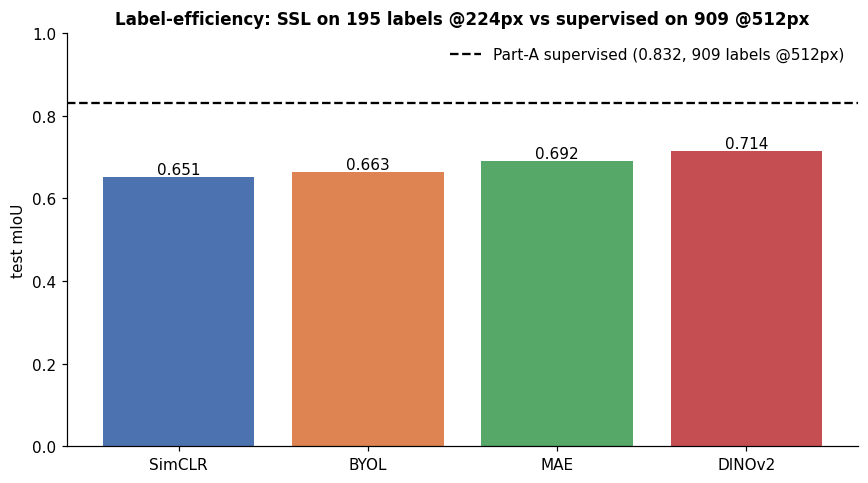

In [3]:
order = [m for m in ["SimCLR","BYOL","MAE","DINOv2"] if m in pb]
mious = [pb[m]["miou"] for m in order]
fig, ax = plt.subplots(figsize=(8,4.5))
b = ax.bar(order, mious, color=["#4C72B0","#DD8452","#55A868","#C44E52"][:len(order)])
ax.bar_label(b, fmt="%.3f")
if baseline:
    ax.axhline(baseline["miou"], ls="--", color="k", label=f"Part-A supervised ({baseline['miou']:.3f}, 909 labels @512px)")
ax.set_ylabel("test mIoU"); ax.set_ylim(0,1); ax.legend()
ax.set_title(f"Label-efficiency: SSL on {N_LAB} labels @224px vs supervised on 909 @512px")
plt.tight_layout(); plt.savefig(WORK/"partB_label_efficiency.png", dpi=120, bbox_inches="tight"); plt.show()

## Task F — consolidated error analysis & label-efficiency discussion
Best SSL method (highest test mIoU) recovers the largest share of the fully-supervised performance while using
only ~21% of the labels. Per-image crack-IoU (stored per method) lets us check whether the SSL models fail on the
same images as the Part-A supervised models — see the report's Insights section.

In [4]:
if pb:
    best = max(pb, key=lambda k: pb[k]["miou"])
    print(f"Best SSL method: {best} (mIoU {pb[best]['miou']:.4f})")
    if baseline:
        print(f"= {100*pb[best]['miou']/baseline['miou']:.1f}% of the Part-A supervised mIoU, using {N_LAB}/909 = {100*N_LAB/909:.0f}% of the labels")
    print("\nRanking by label-efficiency (test mIoU):")
    for m in sorted(pb, key=lambda k:-pb[k]['miou']): print(f"  {m:10s} mIoU {pb[m]['miou']:.4f} | crackIoU {pb[m]['crack_iou']:.4f}")

Best SSL method: DINOv2 (mIoU 0.7144)
= 85.9% of the Part-A supervised mIoU, using 195/909 = 21% of the labels

Ranking by label-efficiency (test mIoU):
  DINOv2     mIoU 0.7144 | crackIoU 0.5211
  MAE        mIoU 0.6916 | crackIoU 0.4855
  BYOL       mIoU 0.6634 | crackIoU 0.4420
  SimCLR     mIoU 0.6513 | crackIoU 0.4223
  SimCLR-frozen mIoU 0.6151 | crackIoU 0.3705


## Task F — do the SSL models fail on the *same* images as the Part-A supervised models?
Both Part A and Part B stored **per-image crack IoU** on the identical test split, so we can compare failure modes
directly rather than by eye: we correlate each SSL method's per-image IoU with the Part-A baseline's, and measure
how many of the 20 hardest images they share.

In [5]:
baseA = baseline.get("per_image_crack_iou") if baseline else None
if not baseA:
    print("Part-A per-image IoUs not found — attach the Part-A NB1 output to run this comparison.")
else:
    import pandas as pd, numpy as np
    rows = []
    worst_A = set(pd.Series(baseA).nsmallest(20).index)
    for m in order:
        pi = pb[m].get("per_image_crack_iou", {})
        common = sorted(set(pi) & set(baseA))
        if not common: continue
        a = np.array([baseA[s] for s in common]); b = np.array([pi[s] for s in common])
        ok = ~(np.isnan(a) | np.isnan(b))
        corr = float(np.corrcoef(a[ok], b[ok])[0, 1]) if ok.sum() > 2 else float("nan")
        worst_B = set(pd.Series(pi).nsmallest(20).index)
        rows.append(dict(Method=m, corr_with_PartA=round(corr, 3),
                         shared_worst20=len(worst_A & worst_B),
                         mean_IoU_on_PartA_worst20=round(float(np.nanmean([pi.get(s, np.nan) for s in worst_A])), 3)))
    cmp_df = pd.DataFrame(rows).set_index("Method")
    cmp_df.to_csv(WORK/"partB_failure_overlap.csv")
    print("Per-image crack-IoU agreement with the Part-A supervised baseline:\n")
    print(cmp_df.to_string())
    print("\nHigh correlation + large shared-worst overlap => the SSL models inherit the SAME hard images as the")
    print("supervised baseline (difficulty is data-intrinsic). Low overlap => the SSL encoder fails differently,")
    print("i.e. its pretext task transferred different texture/shape priors. Discuss in report Section 6.7.")

# ---- styled table (best value per column highlighted) ----
try:
    from IPython.display import display
    _acc = [c for c in tbl.columns if c in ("mIoU","CrackIoU","Dice","%_of_supervised")]
    display(tbl.style.format({**{c: "{:.4f}" for c in _acc if c != "%_of_supervised"},
                              **({"%_of_supervised": "{:.1f}"} if "%_of_supervised" in tbl.columns else {}),
                              "Params_M": "{:.1f}", "Labels": "{:.0f}"})
              .highlight_max(subset=_acc, color="#c8e6c9")
              .set_caption("Task E - label-efficiency (green = best; Part-A row uses 909 labels @512px)"))
except Exception as _e:
    print(tbl.to_string())

    # ---- visualise the failure overlap (Task F) ----
    try:
        overlap_chart = True
        fig, ax = plt.subplots(1, 2, figsize=(11, 4))
        ms = list(cmp_df.index)
        b1 = ax[0].bar(ms, cmp_df["corr_with_PartA"], color=[PALETTE.get(m,"#999") for m in ms])
        ax[0].bar_label(b1, fmt="%.2f"); ax[0].set_ylim(-1, 1); ax[0].axhline(0, c="k", lw=.8)
        ax[0].set_ylabel("corr. of per-image IoU"); ax[0].set_title("Agreement with Part-A supervised baseline")
        ax[0].grid(axis="y", alpha=.3)
        b2 = ax[1].bar(ms, cmp_df["shared_worst20"], color=[PALETTE.get(m,"#999") for m in ms])
        ax[1].bar_label(b2); ax[1].set_ylim(0, 20); ax[1].set_ylabel("images (of 20)")
        ax[1].set_title("Shared hardest-20 test images with Part A"); ax[1].grid(axis="y", alpha=.3)
        plt.tight_layout(); plt.savefig(WORK/"taskF_failure_overlap.png", dpi=115, bbox_inches="tight"); plt.show()
    except Exception as e:
        print("overlap chart skipped:", e)

Per-image crack-IoU agreement with the Part-A supervised baseline:

        corr_with_PartA  shared_worst20  mean_IoU_on_PartA_worst20
Method                                                            
SimCLR            0.570               7                      0.246
BYOL              0.668               6                      0.269
MAE               0.712               7                      0.263
DINOv2            0.801              12                      0.290

High correlation + large shared-worst overlap => the SSL models inherit the SAME hard images as the
supervised baseline (difficulty is data-intrinsic). Low overlap => the SSL encoder fails differently,
i.e. its pretext task transferred different texture/shape priors. Discuss in report Section 6.7.


,Backbone,Labels,mIoU,CrackIoU,Dice,Params_M,%_of_supervised
Method,,,,,,,
DINOv2,ViT-S/14,195,0.7144,0.5211,0.8184,25.2,85.9
MAE,ResNet-50,195,0.6916,0.4855,0.7998,42.0,83.1
BYOL,ResNet-50,195,0.6634,0.4420,0.7760,42.0,79.7
SimCLR,ResNet-50,195,0.6513,0.4223,0.7651,42.0,78.3
SimCLR-frozen,ResNet-50,195,0.6151,0.3705,0.7326,42.0,73.9
Part-A supervised (YOLO26s-Sem),YOLO26s-Sem,909,0.8319,0.7051,0.9030,6.5,100.0


### Task E — radar & per-image consistency
The bar chart compares means; the radar shows every metric at once, and the box plot shows the **spread** of
per-image crack IoU (a method can match on the mean yet be far less consistent).

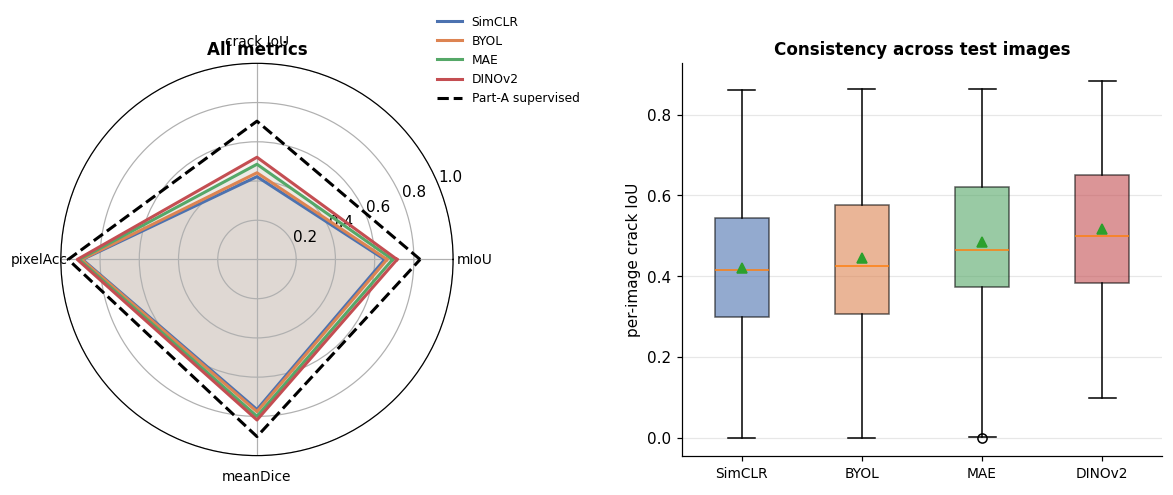

In [6]:
try:
    labels = ["mIoU","crack IoU","pixelAcc","meanDice"]
    ang = np.linspace(0, 2*np.pi, len(labels), endpoint=False).tolist(); ang += ang[:1]
    fig = plt.figure(figsize=(11,4.6))
    axr = plt.subplot(1,2,1, polar=True)
    for m in order:
        r = pb[m]; v = [r["miou"], r["crack_iou"], r["pixel_acc"], r["mdice"]]; v += v[:1]
        axr.plot(ang, v, lw=2, label=m, color=PALETTE.get(m)); axr.fill(ang, v, alpha=.08, color=PALETTE.get(m))
    if baseline:
        v = [baseline["miou"], baseline.get("crack_iou", baseline["per_class_iou"][1]),
             baseline["pixel_acc"], baseline["mdice"]]; v += v[:1]
        axr.plot(ang, v, lw=2, ls="--", color="k", label="Part-A supervised")
    axr.set_xticks(ang[:-1]); axr.set_xticklabels(labels, fontsize=9); axr.set_ylim(0, 1)
    axr.legend(loc="upper right", bbox_to_anchor=(1.35,1.15), fontsize=8); axr.set_title("All metrics")
    axb = plt.subplot(1,2,2)
    data = [[v for v in pb[m].get("per_image_crack_iou", {}).values() if v == v] for m in order]
    bp = axb.boxplot(data, showmeans=True, patch_artist=True)
    for patch, m in zip(bp["boxes"], order): patch.set_facecolor(PALETTE.get(m, "#999")); patch.set_alpha(.6)
    axb.set_xticks(range(1, len(order)+1)); axb.set_xticklabels(order, fontsize=9)
    axb.set_ylabel("per-image crack IoU"); axb.set_title("Consistency across test images"); axb.grid(axis="y", alpha=.3)
    plt.tight_layout(); plt.savefig(WORK/"taskE_radar_box.png", dpi=115, bbox_inches="tight"); plt.show()
except Exception as e: print("radar/box skipped:", e)

### Task E/F — qualitative comparison: all four SSL methods on the same test images
Each method notebook saved its predictions for the **same five** test images (chosen deterministically by crack
density), so we can show them side by side without reloading any checkpoint.

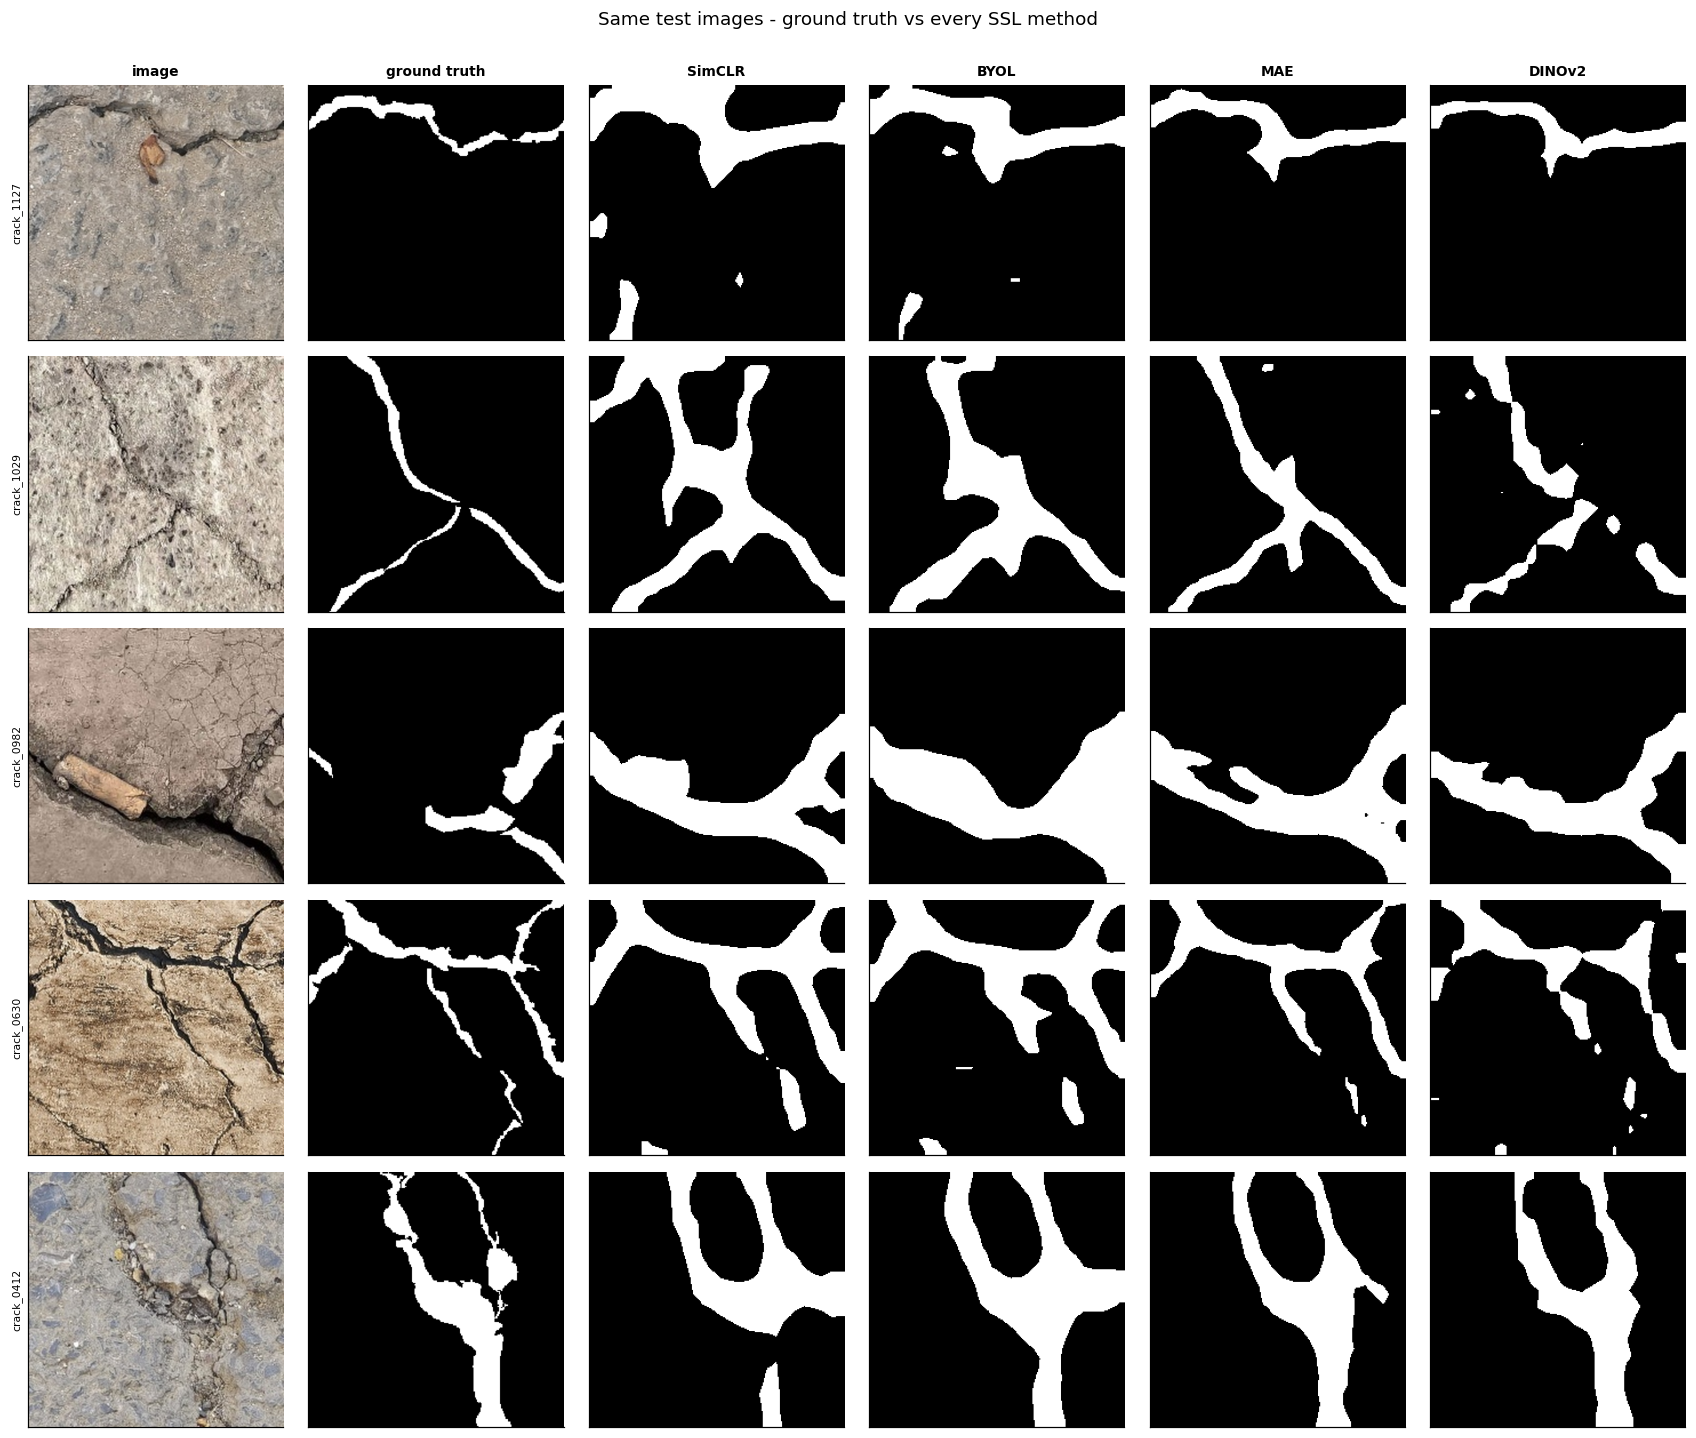

In [7]:
try:
    import glob as _g
    from PIL import Image as _I
    qz = {}
    for f_ in _g.glob("/kaggle/input/**/*_qual_preds.npz", recursive=True):
        tag = Path(f_).name.replace("_qual_preds.npz", "")
        d = np.load(f_); qz[tag] = {str(s): p for s, p in zip(d["ids"], d["preds"])}
    if not qz:
        print("no *_qual_preds.npz found - attach the method-notebook outputs")
    else:
        methods = [m for m in ["SimCLR","BYOL","MAE","DINOv2"] if m in qz]
        sids = list(next(iter(qz.values())).keys())[:5]
        IMGS = _g.glob("/kaggle/input/**/images/images/*.jpg", recursive=True) or _g.glob("/kaggle/input/**/images/**/*.jpg", recursive=True)
        MASKS = _g.glob("/kaggle/input/**/masks/**/*.png", recursive=True)
        P = {Path(x).name: x for x in IMGS}; M_ = {Path(x).name: x for x in MASKS}
        cols = ["image","ground truth"] + methods
        fig, ax = plt.subplots(len(sids), len(cols), figsize=(2.6*len(cols), 2.6*len(sids))); ax = np.atleast_2d(ax)
        for i, sid in enumerate(sids):
            im = np.array(_I.open(P[sid + ".jpg"]).convert("RGB")); gt = np.array(_I.open(M_[sid + ".png"])) > 0
            panels = [im, gt.astype(np.uint8)] + [qz[m][sid] for m in methods]
            for j, pnl in enumerate(panels):
                ax[i,j].imshow(pnl if j == 0 else pnl, cmap=None if j == 0 else "gray")
                if i == 0: ax[i,j].set_title(cols[j], fontsize=9)
                ax[i,j].set_xticks([]); ax[i,j].set_yticks([])
            ax[i,0].set_ylabel(sid, fontsize=7)
        plt.suptitle("Same test images - ground truth vs every SSL method", y=1.002)
        plt.tight_layout(); plt.savefig(WORK/"taskF_qualitative_grid.png", dpi=110, bbox_inches="tight"); plt.show()
except Exception as e: print("qualitative grid skipped:", e)

**NB5 complete.** Saved the label-efficiency table + chart. These feed report §6.6 (Results) and §6.8 (Label-Efficiency).